# Baku, before lights out

Predicting the 2026 Azerbaijan Grand Prix finishing order from practice, qualifying and recent form.

## Setup

If this cell installs packages, restart the kernel once before running the rest.

In [1]:
import importlib.metadata
import subprocess
import sys

packages = {
    "fastf1": "3.6.1",
    "openpyxl": "3.1.5",
    "requests": "2.32.4",
    "numpy": "2.2.6",
    "pandas": "2.2.3",
    "matplotlib": "3.10.3",
    "scipy": "1.15.3",
    "scikit-learn": "1.6.1",
    "xgboost": "3.0.5",
}
if globals().get("restart_needed", False):
    raise RuntimeError("Restart the kernel, then run all cells.")
missing = []
for name, version in packages.items():
    try:
        installed = importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        installed = None
    if installed != version:
        missing.append(f"{name}=={version}")
if missing:
    restart_needed = True
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    raise RuntimeError("Setup complete. Restart the kernel, then run all cells.")

In [2]:
from pathlib import Path
from collections import defaultdict
import json
import time
import tempfile
import unicodedata
import fastf1
import numpy as np
import numpy.strings
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from IPython.utils.capture import capture_output

SEED = 42
AS_OF_UTC = pd.Timestamp("2026-09-25T14:43:00Z")
START_YEAR, TARGET_YEAR = 2018, 2026
TARGET_ROUND = 15
RACE_START = pd.Timestamp("2026-09-26T11:00:00Z")
TIMING_START_YEAR = 2023
N_SIMULATIONS = 6000
OUT = Path("results")
OUT.mkdir(exist_ok=True)
CACHE = Path(tempfile.gettempdir()) / "baku-fastf1-2026"
CACHE.mkdir(exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE))
fastf1.set_log_level("WARNING")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 14,
        "font.size": 10,
    }
)


def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / f"{name}.png", bbox_inches="tight")
    plt.show()

## Get the data

FastF1 provides historical results, qualifying, FP1, FP2 and FP3. The workbook supplies
the current weekend; the grid CSV adds documented penalties. Missing practice sessions
remain missing, and reserve-driver laps are not reassigned to race drivers. Weather comes
from the timestamped JSON and remains context. The first download can take a while.

In [3]:
def retry(fn, attempts=4):
    for attempt in range(attempts):
        try:
            return fn()
        except Exception as exc:
            if attempt == attempts - 1:
                raise
            delay = (
                min(60, 20 * (attempt + 1))
                if "Too Many Requests" in str(exc)
                else 2 ** attempt
            )
            print(
                f"Retrying public data request in {delay}s: {type(exc).__name__}",
                flush=True,
            )
            time.sleep(delay)


def name_key(value):
    value = (
        unicodedata.normalize("NFKD", str(value))
        .encode("ascii", "ignore")
        .decode()
        .lower()
    )
    return "".join(c for c in value if c.isalnum())


def seconds(value):
    if pd.isna(value) or str(value).strip() in ("", "-", "DNF", "DNS", "No time"):
        return np.nan
    if isinstance(value, (pd.Timedelta,)):
        return value.total_seconds()
    s = str(value).strip().strip('"').strip("'").rstrip("s").lstrip("+")
    if ":" in s:
        parts = [float(x) for x in s.split(":")]
        return sum(x * 60 ** i for i, x in enumerate(parts[::-1]))
    return float(s)


def qualify_features(q):
    q = q.copy()
    n = len(q)
    q["qual_norm"] = (q.qual_pos - 1) / max(n - 1, 1)
    for seg in ["Q1", "Q2", "Q3"]:
        q[seg] = q[seg].map(seconds)
        best = q[seg].min()
        q[f"{seg.lower()}_gap_pct"] = 100 * (q[seg] / best - 1)
    # Q1 has broadest coverage. Never compare a Q1 time with a Q3 pole time.
    q["qual_teammate_gap"] = q.q1_gap_pct - q.groupby(
        "constructorId"
    ).q1_gap_pct.transform("mean")
    q["team_qual_norm"] = q.groupby("constructorId").qual_norm.transform("mean")
    return q


def read_weekend(path):
    book = pd.read_excel(path, sheet_name=None)
    tabs = {name_key(k): v.dropna(how="all") for k, v in book.items()}
    keys = [k for k in tabs if k.startswith("qual")]
    if len(keys) != 1:
        raise ValueError("Workbook must contain exactly one qualifying tab.")
    q = tabs[keys[0]].rename(
        columns={
            "Pos.": "qual_pos",
            "No.": "number",
            "Driver": "driver",
            "Team": "team",
        }
    )
    required = {"qual_pos", "number", "driver", "team", "Q1", "Q2", "Q3"}
    if not required <= set(q):
        raise ValueError(f"Qualifying missing columns: {required - set(q)}")
    q["name_key"] = q.driver.map(name_key)
    if not q.name_key.is_unique or not q.number.is_unique:
        raise ValueError("Duplicate qualifying identity.")
    q.qual_pos = pd.to_numeric(q.qual_pos, errors="raise").astype(int)
    if sorted(q.qual_pos) != list(range(1, len(q) + 1)):
        raise ValueError("Qualifying positions must be a complete unique order.")
    practice = []
    for session in ["fp1", "fp2", "fp3"]:
        if session not in tabs:
            continue
        p = tabs[session].rename(
            columns={
                "Pos.": "practice_pos",
                "No.": "number",
                "Driver": "driver",
                "Team": "team",
                "Laps": "laps",
            }
        )
        p["name_key"] = p.driver.map(name_key)
        if not p.name_key.is_unique or not set(p.name_key) <= set(q.name_key):
            raise ValueError(f"{session}: duplicate or unknown drivers.")
        leader = p.loc[p.practice_pos.eq(1), "Time / Gap"]
        if len(leader) != 1 or ":" not in str(leader.iloc[0]):
            raise ValueError(f"{session}: leader must have an absolute lap time.")
        best = seconds(leader.iloc[0])

        def lap_time(v):
            return seconds(v) if ":" in str(v) else best + seconds(v)

        p["best_seconds"] = p["Time / Gap"].map(lap_time)
        p["gap_pct"] = 100 * (p.best_seconds / best - 1)
        p["session"] = session.upper()
        practice.append(p)
    return q, pd.concat(practice, ignore_index=True) if practice else pd.DataFrame()


def season_table(year, kind, cache, snapshot="2026-09-25"):
    from fastf1.ergast import Ergast

    cache = Path(cache)
    cache.mkdir(parents=True, exist_ok=True)
    path = cache / f"{kind}_{year}_{snapshot}.pkl"
    if path.exists():
        return pd.read_pickle(path)  # Only load your own generated cache.
    api = Ergast(limit=1000)
    fn = api.get_race_results if kind == "results" else api.get_qualifying_results
    time.sleep(1.5)
    page = retry(lambda: fn(season=year))
    chunks, received = [], 0
    while True:
        for (_, meta), result in zip(page.description.iterrows(), page.content):
            f = pd.DataFrame(result).copy()
            for col in [
                "season",
                "round",
                "raceDate",
                "raceTime",
                "circuitId",
                "raceName",
            ]:
                if col in meta:
                    f[col] = meta[col]
            chunks.append(f)
            received += len(f)
        if received >= page.total_results:
            break
        time.sleep(1.5)
        page = retry(page.get_next_result_page)
    frame = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
    if not frame.empty:
        if frame.duplicated(["season", "round", "driverId"]).any():
            raise ValueError("Duplicate API results across pages.")
        frame.to_pickle(path)
    return frame


def load_history(start_year, target_year, race_start, cache, snapshot):
    results, quals = [], []
    for year in range(start_year, target_year + 1):
        print(f"Historical results and qualifying: {year}", flush=True)
        results.append(season_table(year, "results", cache, snapshot))
        quals.append(season_table(year, "qualifying", cache, snapshot))
    r, q = pd.concat(results, ignore_index=True), pd.concat(quals, ignore_index=True)
    r["date"] = pd.to_datetime(r.raceDate, utc=True)
    # Exclude the entire target day; no target-race labels enter any computation.
    r = r.loc[r.date < pd.Timestamp(race_start).normalize()].copy()
    r["race_id"] = r.season.astype(str) + "-" + r["round"].astype(str).str.zfill(2)
    r["position"] = pd.to_numeric(r.position, errors="raise")
    r["grid"] = pd.to_numeric(r.grid, errors="raise")
    r["driver"] = r.givenName + " " + r.familyName
    r["team"] = r.constructorName
    r["n"] = r.groupby("race_id").driverId.transform("size")
    r["finish_norm"] = (r.position - 1) / (r.n - 1)
    # Non-finish proxy includes accidents, mechanical failures and exclusions.
    # It is explicitly not a pure mechanical-failure probability.
    r["nonfinish"] = (
        ~r.status.fillna("").str.match(r"^(Finished|Lapped|\+\d+ Laps?)$")
    ).astype(float)
    r["gain_norm"] = (r.grid.where(r.grid.gt(0)) - r.position) / (r.n - 1)
    if r.duplicated(["race_id", "driverId"]).any():
        raise ValueError("Duplicate history keys.")
    for race, g in r.groupby("race_id"):
        if len(g) < 18 or sorted(g.position) != list(range(1, len(g) + 1)):
            raise ValueError(f"Incomplete finishing classification: {race}")
    q = q.rename(columns={"position": "qual_pos"})
    for col in ["Q1", "Q2", "Q3"]:
        if col not in q:
            q[col] = np.nan
    q = q[["season", "round", "driverId", "qual_pos", "Q1", "Q2", "Q3"]]
    r = r.merge(
        q, on=["season", "round", "driverId"], how="left", validate="one_to_one"
    )
    coverage = r.groupby("race_id").qual_pos.apply(lambda x: x.notna().mean())
    if (coverage < 0.8).any():
        raise ValueError(
            f"Qualifying coverage below 80%: {coverage[coverage < .8].to_dict()}"
        )
    r = pd.concat(
        [qualify_features(g) for _, g in r.groupby("race_id")], ignore_index=True
    )
    r["grid_norm"] = (r.grid.where(r.grid.gt(0), r.n + 1) - 1) / (r.n - 1)
    return r.sort_values(["date", "race_id", "driverId"]).reset_index(drop=True)


def match_field(q, history):
    lookup = history.sort_values("date").drop_duplicates("driverId", keep="last").copy()
    lookup["name_key"] = lookup.driver.map(name_key)
    # Explicit spelling aliases, never fuzzy joins or car-number joins.
    aliases = {"kimiantonelli": "andreakimiantonelli", "alexalbon": "alexanderalbon"}
    available = set(lookup.name_key)
    q = q.copy()
    q.name_key = q.name_key.map(
        lambda x: aliases.get(x, x) if aliases.get(x, x) in available else x
    )
    f = q.merge(
        lookup[["name_key", "driverId"]],
        on="name_key",
        how="left",
        validate="one_to_one",
    )
    if f.driverId.isna().any():
        raise ValueError(
            "Unmatched drivers; add a verified alias: "
            + ", ".join(f.loc[f.driverId.isna(), "driver"])
        )
    # Resolve constructors from current-season IDs, allowing known display-name changes.
    teams = (
        history.loc[history.season.eq(history.season.max())]
        .sort_values("date")
        .drop_duplicates("constructorId", keep="last")
    )
    tm = dict(zip(teams.team.map(name_key), teams.constructorId))
    tm_alias = {
        "redbullracing": "red_bull",
        "haasf1team": "haas",
        "racingbulls": "rb",
        "alpine": "alpine",
        "audi": "audi",
        "cadillac": "cadillac",
    }
    known_ids = set(teams.constructorId)

    def team_id(t):
        k = name_key(t)
        if k in tm:
            return tm[k]
        alias = tm_alias.get(k)
        if alias in known_ids:
            return alias
        raise ValueError(f"Unmapped constructor: {t}; available: {tm}")

    f["constructorId"] = f.team.map(team_id)
    return qualify_features(f)


def add_weekend_summary(field, practice):
    f = field.copy()
    # Preserve original name matching for practice, including accented spellings.
    f["_join"] = f.driver.map(name_key)
    for sess in ["FP1", "FP2", "FP3"]:
        p = practice.loc[
            practice.session.eq(sess), ["name_key", "gap_pct", "laps"]
        ].copy()
        p.columns = ["_join", f"{sess.lower()}_gap_pct", f"{sess.lower()}_laps"]
        f = f.merge(p, on="_join", how="left", validate="one_to_one")
    for sess in ["fp1", "fp2", "fp3"]:
        f[f"{sess}_team_gap_pct"] = f.groupby("constructorId")[f"{sess}_gap_pct"].transform("mean")
    return f.drop(columns="_join")


def apply_grid(field, path, cutoff):
    f = field.copy()
    f["grid"] = f.qual_pos
    f["grid_source"] = "Qualifying proxy; penalties/pit-lane starts unconfirmed"
    f["grid_status"] = "Qualifying proxy; penalties/pit-lane starts unconfirmed"
    if Path(path).exists():
        g = pd.read_csv(path)
        if "grid_status" not in g:
            g["grid_status"] = "User-supplied grid; confirmation status unspecified"
        required = {"driverId", "grid", "source_url", "published_at"}
        if (
            not required <= set(g)
            or set(g.driverId) != set(f.driverId)
            or not g.driverId.is_unique
        ):
            raise ValueError(
                "Grid CSV must contain one sourced row per entered driver."
            )
        if (
            g[list(required)].isna().any().any()
            or (pd.to_datetime(g.published_at, utc=True) > cutoff).any()
        ):
            raise ValueError("Grid source missing or published after cutoff.")
        if ((g.grid < 0) | (g.grid > len(f))).any() or g.loc[
            g.grid.gt(0), "grid"
        ].duplicated().any():
            raise ValueError("Invalid starting grid; use 0 for pit-lane starters.")
        f = f.drop(columns=["grid", "grid_source", "grid_status"]).merge(
            g.rename(columns={"source_url": "grid_source"}),
            on="driverId",
            validate="one_to_one",
        )
    f["grid_norm"] = (f.grid.where(f.grid.gt(0), len(f) + 1) - 1) / (len(f) - 1)
    return f

In [4]:
def summarize_laps(laps, results, identity_map=None):
    """Use the same FP2 rules for historical races and the current weekend."""
    l = pd.DataFrame(laps).copy()
    l["sec"] = pd.to_timedelta(l.LapTime).dt.total_seconds()
    mapping = (
        identity_map if identity_map is not None
        else dict(zip(results.DriverNumber.astype(str), results.DriverId))
    )
    mapping = {str(k): v for k, v in mapping.items() if pd.notna(v) and str(v).strip()}
    l["driverId"] = l.DriverNumber.astype(str).map(mapping)
    session_valid = l.sec.gt(0)
    if "Deleted" in l:
        session_valid &= ~l.Deleted.eq(True)
    session_best = l.loc[session_valid, "sec"].min()
    l = l.loc[l.driverId.notna()]
    if l.empty:
        return pd.DataFrame()
    deleted = l["Deleted"].eq(True) if "Deleted" in l else pd.Series(False, index=l.index)
    clean = l.loc[
        l.IsAccurate.fillna(False)
        & l.PitInTime.isna()
        & l.PitOutTime.isna()
        & l.TrackStatus.astype(str).eq("1")
        & l.sec.gt(0)
        & ~deleted
    ].copy()

    # Keep the 7% tolerance, anchored to each driver's fastest clean stint lap.
    # A slow block median can otherwise let cooldown laps qualify as race pace.
    reference = clean.groupby(["driverId", "Stint", "Compound"]).sec.transform("min")
    pace_laps = clean.loc[clean.sec.le(reference * 1.07)].copy()
    pace_laps["time_bin"] = (
        pd.to_timedelta(pace_laps.Time).dt.total_seconds() // 600
    )
    pace_laps["pace_residual"] = pace_laps.sec - pace_laps.groupby(
        ["Compound", "time_bin"]
    ).sec.transform("median")
    best = l.loc[l.sec.gt(0) & ~deleted].groupby("driverId").sec.min()
    rows = []
    for driver, recorded in l.groupby("driverId"):
        g = pace_laps.loc[pace_laps.driverId.eq(driver)]
        slopes, pace = [], []
        longest = 0
        for _, stint in g.groupby(["Stint", "Compound"]):
            stint = stint.sort_values("LapNumber")
            # Split AFTER filtering: an excluded lap must break the run.
            block = stint.LapNumber.diff().ne(1).cumsum()
            for _, run in stint.groupby(block):
                longest = max(longest, len(run))
                if len(run) >= 5 and run.TyreLife.notna().all() and run.TyreLife.nunique() >= 4:
                    from scipy.stats import theilslopes

                    slopes.append(theilslopes(run.sec, run.TyreLife).slope)
                    pace.extend(run.pace_residual.tolist())
        rows.append({
            "driverId": driver,
            "fp2_gap_pct": 100 * (best.get(driver, np.nan) / session_best - 1),
            "fp2_laps": int(recorded.LapNumber.nunique()),
            "fp2_clean_laps": int(clean.loc[clean.driverId.eq(driver), "LapNumber"].nunique()),
            "fp2_pace_laps": int(g.LapNumber.nunique()),
            "fp2_longest_run": longest,
            "fp2_longrun_delta": float(np.median(pace)) if pace else np.nan,
            "fp2_stint_slope": float(np.median(slopes)) if slopes else np.nan,
            "fp2_longrun_laps": len(pace),
        })
    return pd.DataFrame(rows)


def load_fp2(year, rnd, cache, identity_map=None):
    import fastf1

    path = Path(cache) / f"fp2_v5_{year}_{rnd}.pkl"
    if path.exists():
        return pd.read_pickle(path)
    absent = Path(cache) / f"fp2_missing_{year}_{rnd}.json"
    if absent.exists():
        raise ValueError(json.loads(absent.read_text())["reason"])
    s = fastf1.get_session(int(year), int(rnd), "FP2")
    s.load(telemetry=False, weather=False, messages=True)
    if not s.laps.Deleted.notna().all():
        raise ValueError("Practice lap-deletion flags unavailable; retry this session")
    out = summarize_laps(s.laps, s.results, identity_map)
    if out.empty:
        raise ValueError("No usable FP2 laps")
    if not out.driverId.is_unique or out.driverId.eq("").any():
        raise ValueError("Invalid FP2 driver identities")
    out.to_pickle(path)
    return out


def load_practice(year, rnd, session, cache):
    """Session summaries; reserve-driver laps retain their own identity."""
    if session == "FP2":
        return load_fp2(year, rnd, cache)
    prefix = session.lower()
    path = Path(cache) / f"practice_v3_{prefix}_{year}_{rnd}.pkl"
    if path.exists():
        return pd.read_pickle(path)
    s = fastf1.get_session(int(year), int(rnd), session)
    s.load(telemetry=False, weather=False, messages=True)
    if not s.laps.Deleted.notna().all():
        raise ValueError("Practice lap-deletion flags unavailable; retry this session")
    laps = pd.DataFrame(s.laps).copy()
    laps["seconds"] = pd.to_timedelta(laps.LapTime).dt.total_seconds()
    mapping = dict(zip(s.results.DriverNumber.astype(str), s.results.DriverId))
    mapping = {str(k): v for k, v in mapping.items() if pd.notna(v) and str(v).strip()}
    laps["driverId"] = laps.DriverNumber.astype(str).map(mapping)
    if not laps.driverId.notna().any():
        raise ValueError("No practice laps with resolved driver identities")
    valid = laps.seconds.gt(0)
    if "Deleted" in laps:
        valid &= ~laps.Deleted.eq(True)
    # Include the session leader in the reference even if they are a reserve driver.
    session_best = laps.loc[valid, "seconds"].min()
    best = laps.loc[valid & laps.driverId.notna()].groupby("driverId").seconds.min()
    if best.empty:
        raise ValueError("No valid practice lap times")
    out = laps.loc[laps.driverId.notna()].groupby("driverId").LapNumber.nunique().rename(f"{prefix}_laps").to_frame()
    out[f"{prefix}_gap_pct"] = 100 * (best / session_best - 1)
    out = out.reset_index()
    out.to_pickle(path)
    return out


def enrich_practice(history, cache, since=2023):
    h = history.copy()
    log = []
    events = h.loc[h.season.ge(since), ["season", "round", "race_id"]].drop_duplicates()
    for session in ["FP1", "FP2", "FP3"]:
        prefix = session.lower()
        chunks = []
        for row in events.itertuples():
            try:
                print(f"{session} timing {row.race_id}", flush=True)
                f = load_practice(row.season, row.round, session, cache)
                f["race_id"] = row.race_id
                chunks.append(f)
                log.append({"race_id": row.race_id, "session": session, "status": "loaded", "detail": ""})
            except Exception as exc:
                log.append({"race_id": row.race_id, "session": session, "status": "unavailable", "detail": str(exc)[:200]})
        if chunks:
            h = h.merge(pd.concat(chunks), on=["race_id", "driverId"], how="left", validate="one_to_one")
        for col in [f"{prefix}_gap_pct", f"{prefix}_laps"]:
            if col not in h:
                h[col] = np.nan
        h[f"{prefix}_team_gap_pct"] = h.groupby(["race_id", "constructorId"])[f"{prefix}_gap_pct"].transform("mean")
    for col in ["fp2_clean_laps", "fp2_pace_laps", "fp2_longest_run",
                "fp2_longrun_delta", "fp2_stint_slope", "fp2_longrun_laps"]:
        if col not in h:
            h[col] = np.nan
    return h, pd.DataFrame(log)


In [5]:
def load_race_context(year, rnd, cache):
    import fastf1

    path = Path(cache) / f"race_context_v1_{year}_{rnd}.pkl"
    if path.exists():
        return pd.read_pickle(path)
    s = fastf1.get_session(int(year), int(rnd), "R")
    s.load(telemetry=False, weather=True, messages=False)
    weather = s.weather_data
    wet = (
        float(weather.Rainfall.mean() >= 0.05)
        if weather is not None and len(weather)
        else np.nan
    )
    l = pd.DataFrame(s.laps).copy()
    l["sec"] = pd.to_timedelta(l.LapTime).dt.total_seconds()
    l = l.loc[
        l.IsAccurate.fillna(False)
        & l.PitInTime.isna()
        & l.PitOutTime.isna()
        & l.TrackStatus.astype(str).eq("1")
        & l.sec.notna()
    ].copy()
    # Relative race pace from comparable compound, race phase and tyre age.
    # This still includes fuel/traffic confounding; only prior races may use it.
    l["lap_bin"] = l.LapNumber // 5
    l["age_bin"] = l.TyreLife // 5
    grouped = l.groupby(["Compound", "lap_bin", "age_bin"]).sec
    l["residual"] = 100 * (l.sec / grouped.transform("median") - 1)
    l.loc[grouped.transform("size") < 4, "residual"] = np.nan
    mapping = dict(zip(s.results.DriverNumber.astype(str), s.results.DriverId))
    l["driverId"] = l.DriverNumber.astype(str).map(mapping)
    pace = l.groupby("driverId").residual.agg(["median", "count"])
    pace.loc[pace["count"] < 5, "median"] = np.nan
    out = pd.DataFrame({"driverId": list(mapping.values())})
    out["race_pace_delta"] = out.driverId.map(pace["median"])
    out["wet"] = wet
    out["race_id"] = f"{year}-{int(rnd):02d}"
    out["source_url"] = "https://livetiming.formula1.com/"
    out.to_pickle(path)
    return out


def enrich_race_context(history, cache, since=2023, enabled=True):
    h = history.copy()
    chunks = []
    log = []
    if enabled:
        for r in (
            h.loc[h.season.ge(since), ["season", "round", "race_id"]]
            .drop_duplicates()
            .itertuples()
        ):
            try:
                print(f"Prior race pace/weather {r.race_id}", flush=True)
                chunks.append(load_race_context(r.season, r.round, cache))
                log.append({"race_id": r.race_id, "status": "loaded", "detail": ""})
            except Exception as exc:
                log.append(
                    {
                        "race_id": r.race_id,
                        "status": "unavailable",
                        "detail": str(exc)[:200],
                    }
                )
    if chunks:
        extra = pd.concat(chunks, ignore_index=True)
        h = h.merge(
            extra[["race_id", "driverId", "wet", "race_pace_delta"]],
            on=["race_id", "driverId"],
            how="left",
            validate="one_to_one",
            suffixes=("", "_api"),
        )
        for c in ["wet", "race_pace_delta"]:
            if c + "_api" in h:
                h[c] = h[c].fillna(h[c + "_api"])
                h = h.drop(columns=c + "_api")
    for c in ["wet", "race_pace_delta"]:
        if c not in h:
            h[c] = np.nan
    return h, pd.DataFrame(log, columns=["race_id", "status", "detail"])


def weather_snapshot(path, race_start, cutoff, fetch=True):
    """Use a timestamped saved forecast; never replace with realized race weather."""
    path = Path(path)
    if path.exists():
        obj = json.loads(path.read_text())
    elif fetch:
        import requests

        captured = pd.Timestamp.now(tz="UTC")
        if captured > cutoff or captured >= race_start:
            return {
                "status": "unavailable: live retrieval is after cutoff; supply a saved forecast"
            }
        params = {
            "latitude": 40.3725,
            "longitude": 49.8533,
            "hourly": "temperature_2m,precipitation_probability,wind_speed_10m",
            "timezone": "UTC",
            "start_date": race_start.date().isoformat(),
            "end_date": race_start.date().isoformat(),
        }
        response = requests.get(
            "https://api.open-meteo.com/v1/forecast", params=params, timeout=30
        )
        response.raise_for_status()
        obj = {
            "captured_at": captured.isoformat(),
            "source_url": response.url,
            "data": response.json(),
        }
        path.write_text(json.dumps(obj, indent=2))
    else:
        return {"status": "unavailable: no saved pre-race forecast"}
    if pd.Timestamp(obj["captured_at"]) > cutoff:
        raise ValueError("Weather forecast was captured after the prediction cutoff.")
    hourly = pd.DataFrame(obj["data"]["hourly"])
    hourly["time"] = pd.to_datetime(hourly.time, utc=True)
    race_hours = hourly.loc[
        hourly.time.between(race_start, race_start + pd.Timedelta(hours=2))
    ]
    if len(race_hours) < 2:
        raise ValueError("Weather snapshot does not cover the race window.")
    return {
        "status": "forecast context only; no historical forecast training coverage",
        "captured_at": obj["captured_at"],
        "source_url": obj["source_url"],
        "temperature_c": float(race_hours.temperature_2m.mean()),
        "max_hourly_rain_probability": float(
            race_hours.precipitation_probability.max()
        ),
        "max_wind_kmh": float(race_hours.wind_speed_10m.max()),
    }

In [6]:
required_files = ["weekend.xlsx", "grid.csv", "weather_snapshot.json"]
DATA = Path("data") if Path("data/weekend.xlsx").exists() else Path(".")
if not all((DATA / name).exists() for name in required_files):
    try:
        from google.colab import files

        files.upload()
        DATA = Path(".")
    except ImportError:
        raise FileNotFoundError(
            "Place the workbook, grid CSV and weather JSON in data/."
        )

qualifying, practice = read_weekend(DATA / "weekend.xlsx")
with capture_output():
    history = load_history(
        START_YEAR, TARGET_YEAR, RACE_START, CACHE, AS_OF_UTC.date().isoformat()
    )
assert history.season.max() == TARGET_YEAR
assert history.date.max() < AS_OF_UTC < RACE_START
field = add_weekend_summary(match_field(qualifying, history), practice)
field = apply_grid(field, DATA / "grid.csv", AS_OF_UTC)
field["season"] = TARGET_YEAR
field["circuitId"] = "baku"
field["date"] = RACE_START.normalize()
field["race_id"] = f"{TARGET_YEAR}-baku"
field["n"] = len(field)
assert not history.duplicated(["race_id", "driverId"]).any()
assert field.driverId.is_unique

display(
    history.groupby("season").agg(
        races=("race_id", "nunique"), starts=("driverId", "size")
    )
)
print(
    f"Current field: {len(field)} drivers | History through {history.date.max().date()}"
)

,races,starts
season,,
2018,21,420
2019,21,420
2020,17,340
2021,22,440
2022,22,440
2023,22,440
2024,24,479
2025,24,479
2026,14,308


Current field: 22 drivers | History through 2026-09-13


In [7]:
with capture_output():
    history, context_log = enrich_race_context(history, CACHE, since=TIMING_START_YEAR)
    history, timing_log = enrich_practice(history, CACHE, since=TIMING_START_YEAR)

unavailable = timing_log.loc[timing_log.status.eq("unavailable")]
unexpected = unavailable.loc[~unavailable.detail.str.contains("does not exist for this event", na=False)]
if not unexpected.empty:
    display(unexpected)
    raise RuntimeError("Practice extraction is incomplete. Resolve the listed download errors and rerun this cell.")

long_run_columns = [
    "fp2_clean_laps", "fp2_pace_laps", "fp2_longest_run",
    "fp2_longrun_delta", "fp2_stint_slope", "fp2_longrun_laps",
]
field[long_run_columns] = np.nan
try:
    weekend_identity = dict(zip(field.number.astype(int).astype(str), field.driverId))
    extra = load_fp2(TARGET_YEAR, TARGET_ROUND, CACHE, identity_map=weekend_identity)
    field = field.drop(columns=long_run_columns).merge(
        extra[["driverId", *long_run_columns]],
        on="driverId",
        how="left",
        validate="one_to_one",
    )
except Exception as exc:
    print(f"Current FP2 long runs unavailable: {exc}")

weather = weather_snapshot(
    DATA / "weather_snapshot.json", RACE_START, AS_OF_UTC, fetch=False
)
display(pd.Series(weather, name="Race-window weather"))
display(context_log.status.value_counts().rename("Historical race context"))
display(pd.crosstab(timing_log.session, timing_log.status))
context_log.to_csv(OUT / "race_context_availability.csv", index=False)
timing_log.to_csv(OUT / "practice_availability.csv", index=False)

core        WARNING 	No lap data for driver 10


core        WARNING 	No lap data for driver 31


core        WARNING 	No lap data for driver 44


core        WARNING 	No lap data for driver 63


core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 10)


...

core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 11)


core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)


status                         forecast context only; no historical forecast ...
captured_at                                     2026-09-25T14:42:21.819852+00:00
source_url                     https://api.open-meteo.com/v1/forecast?latitud...
temperature_c                                                          26.266667
max_hourly_rain_probability                                                  0.0
max_wind_kmh                                                                17.6
Name: Race-window weather, dtype: object

status
loaded    84
Name: Historical race context, dtype: int64

status,loaded,unavailable
session,,
FP1,84,0
FP2,61,23
FP3,61,23


## The weekend so far

Clean timing laps and sustained long runs are different. The table below shows what
survives each FP2 filter. A candidate long run needs five consecutive laps on the same
stint and compound, each within 7% of that stint's fastest clean lap. This is a timing
heuristic; fuel load and run plans remain unknown.

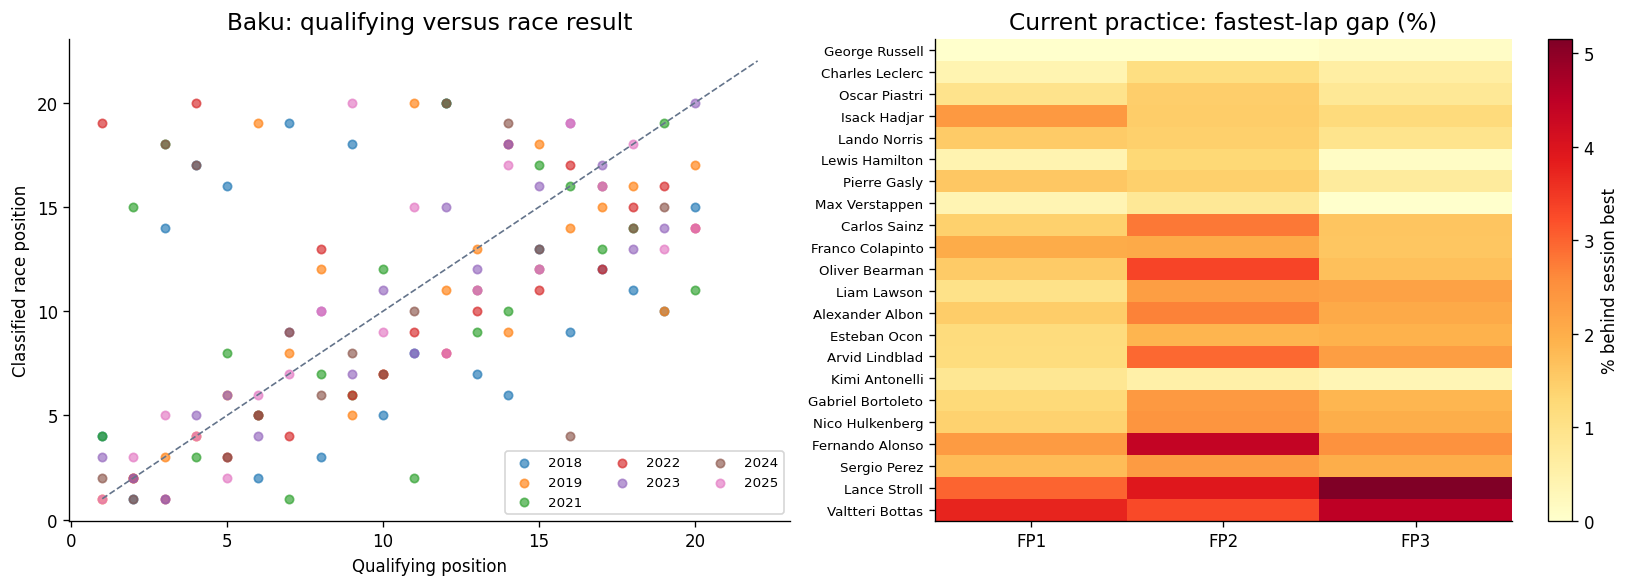

In [8]:
(fig, axes) = plt.subplots(1, 2, figsize=(14, 5))
baku_history = history.loc[history.circuitId.eq("baku")]
for (year, g) in baku_history.groupby("season"):
    axes[0].scatter(g.qual_pos, g.position, alpha=0.65, label=str(year), s=25)
axes[0].plot([1, 22], [1, 22], color="#64748b", linestyle="--", linewidth=1)
axes[0].set(
    xlabel="Qualifying position",
    ylabel="Classified race position",
    title="Baku: qualifying versus race result",
)
axes[0].legend(ncol=3, fontsize=8)
pace = practice.pivot(index="driver", columns="session", values="gap_pct").reindex(
    qualifying.sort_values("qual_pos").driver
)
im = axes[1].imshow(pace, aspect="auto", cmap="YlOrRd")
axes[1].set_yticks(range(len(pace)), pace.index, fontsize=8)
axes[1].set_xticks(range(len(pace.columns)), pace.columns)
axes[1].set_title("Current practice: fastest-lap gap (%)")
fig.colorbar(im, ax=axes[1], label="% behind session best")
savefig("eda_baku_and_practice")

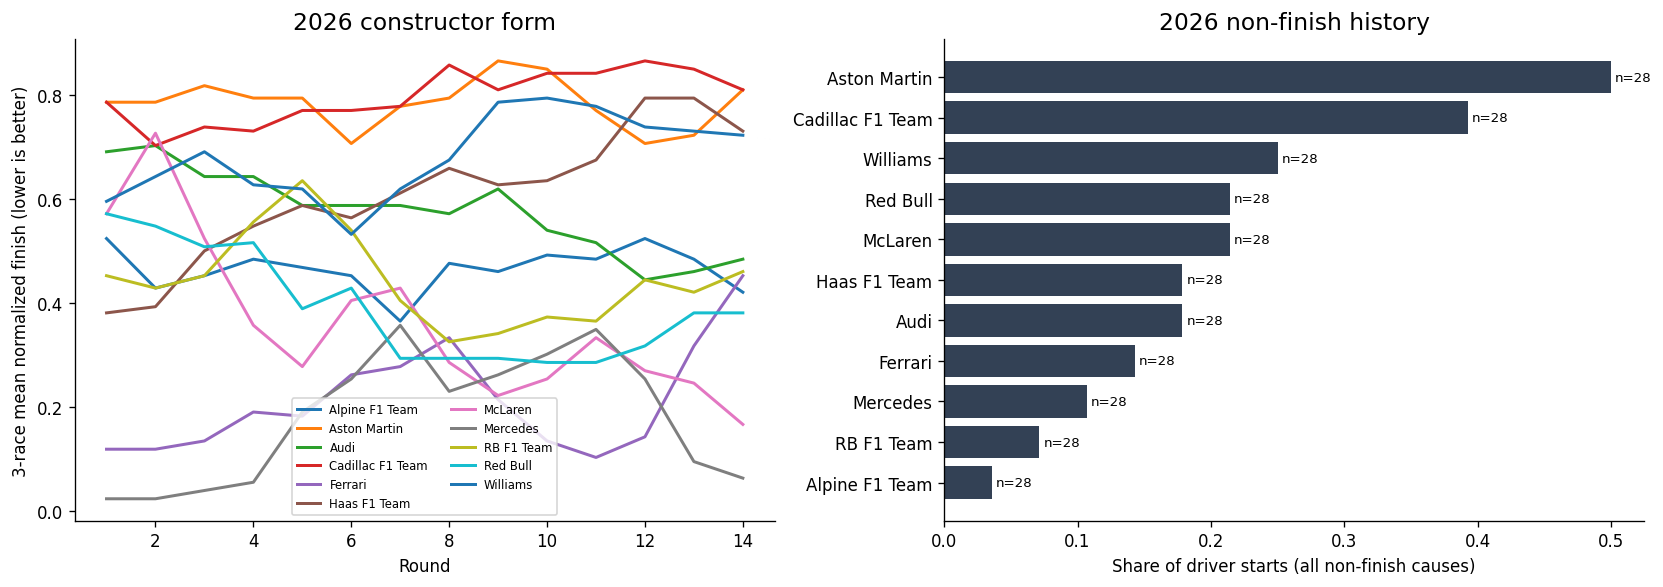

In [9]:
recent = history.loc[history.season.eq(TARGET_YEAR)].copy()
(fig, axes) = plt.subplots(1, 2, figsize=(14, 5))
for (team, g) in recent.groupby("team"):
    means = g.groupby("round").finish_norm.mean().rolling(3, min_periods=1).mean()
    axes[0].plot(means.index, means, label=team, linewidth=1.8)
axes[0].set(
    title="2026 constructor form",
    xlabel="Round",
    ylabel="3-race mean normalized finish (lower is better)",
)
axes[0].legend(fontsize=7, ncol=2)
rel = recent.groupby("team").nonfinish.agg(["mean", "size"]).sort_values("mean")
axes[1].barh(rel.index, rel["mean"], color="#334155")
for (i, r) in enumerate(rel.itertuples()):
    axes[1].text(r.mean + 0.003, i, f"n={r.size}", va="center", fontsize=8)
axes[1].set(
    title="2026 non-finish history",
    xlabel="Share of driver starts (all non-finish causes)",
)
savefig("eda_constructor_and_reliability")

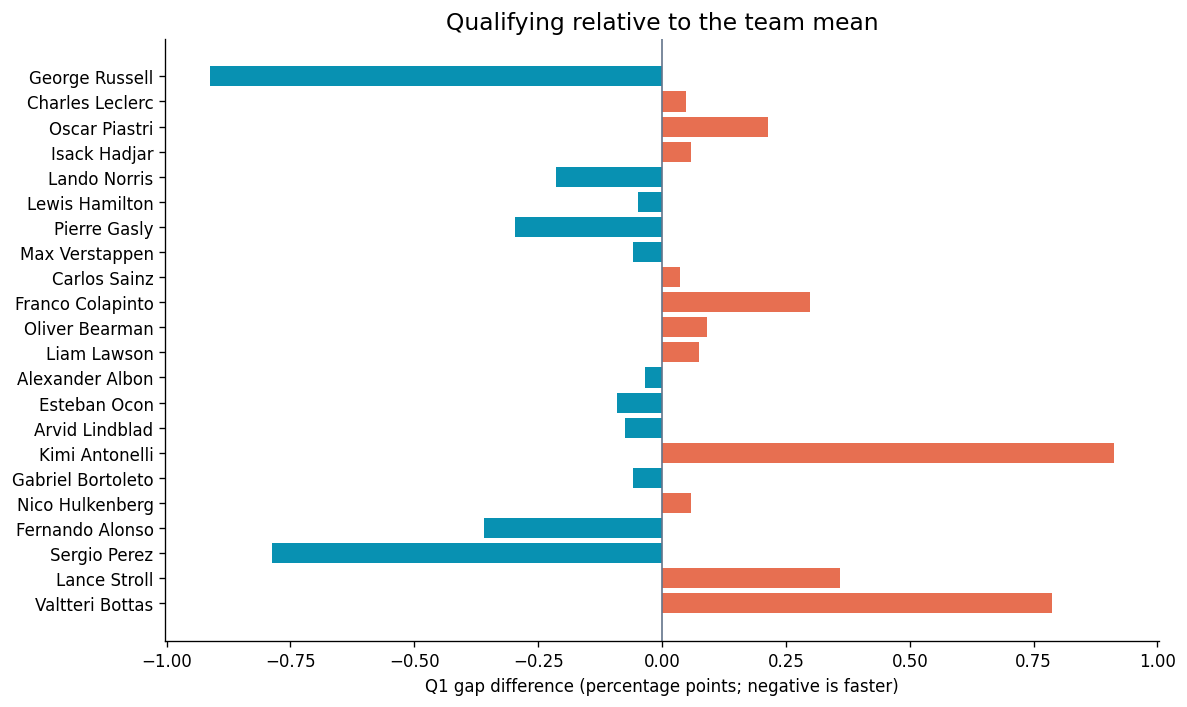

,Clean timing laps,After pace filter,Longest consecutive block,Candidate long-run laps
Driver,,,,
George Russell,12,9,3,0
Charles Leclerc,11,6,3,0
Oscar Piastri,10,8,4,0
Isack Hadjar,10,7,3,0
Lando Norris,12,9,3,0
Lewis Hamilton,10,7,3,0
Pierre Gasly,11,8,3,0
Max Verstappen,13,8,1,0
Carlos Sainz,9,7,4,0


Timing available: 22/22 drivers; clean laps: 22; candidate long runs: 0.
Long-run pace, slope and lap count are diagnostics only, excluded from modeling.


,starts,nonfinish_rate
wet,,
0.0,1504,0.138298
1.0,202,0.178218


In [10]:
(fig, ax) = plt.subplots(figsize=(10, 6))
g = field.sort_values("qual_pos")
ax.barh(
    g.driver,
    g.qual_teammate_gap,
    color=np.where(g.qual_teammate_gap < 0, "#0891b2", "#e76f51"),
)
ax.axvline(0, color="#64748b", linewidth=1)
ax.invert_yaxis()
ax.set(
    title="Qualifying relative to the team mean",
    xlabel="Q1 gap difference (percentage points; negative is faster)",
)
savefig("eda_teammate_qualifying")
fp2_coverage = field[[
    "driver", "fp2_clean_laps", "fp2_pace_laps", "fp2_longest_run", "fp2_longrun_laps"
]].copy()
display(fp2_coverage.rename(columns={
    "driver": "Driver", "fp2_clean_laps": "Clean timing laps",
    "fp2_pace_laps": "After pace filter", "fp2_longest_run": "Longest consecutive block",
    "fp2_longrun_laps": "Candidate long-run laps",
}).set_index("Driver"))
available = field.fp2_clean_laps.notna().sum()
usable = field.fp2_clean_laps.gt(0).sum()
long_runs = field.fp2_longrun_laps.gt(0).sum()
print(f"Timing available: {available}/{len(field)} drivers; clean laps: {usable}; "
      f"candidate long runs: {long_runs}.")
print("Long-run pace, slope and lap count are diagnostics only, excluded from modeling.")
fp2_coverage.to_csv(OUT / "fp2_lap_coverage.csv", index=False)
if history.wet.notna().any():
    display(
        history.groupby("wet").agg(
            starts=("driverId", "size"), nonfinish_rate=("nonfinish", "mean")
        )
    )
else:
    print(
        "Wet/dry performance unavailable: no labeled historical race-weather context supplied."
    )

## Features before each race

Driver and team form use earlier results. Circuit and wet/dry estimates are shrunk toward
a neutral prior when there is little history. A race updates the history only after its features are built.

Long-run pace, slope and lap count are excluded together: the corrected target data
has no qualifying five-lap runs.

In [11]:
STREET_CIRCUITS = {"baku", "monaco", "marina_bay", "jeddah", "vegas"}


def build_features(history, target):
    drivers, teams, circuit_drivers, streets = (
        defaultdict(list),
        defaultdict(list),
        defaultdict(list),
        defaultdict(list),
    )
    circuit_races = defaultdict(list)
    rows = []

    def mean(records, col, last=5):
        v = [r.get(col, np.nan) for r in records[-last:]]
        return float(np.nanmean(v)) if np.isfinite(v).any() else np.nan

    def shrink(records, col, prior=0.0, strength=5):
        v = [r[col] for r in records if np.isfinite(r.get(col, np.nan))]
        return (sum(v) + strength * prior) / (len(v) + strength)

    def make(r):
        d = drivers[r.driverId]
        t = teams[(r.season, r.constructorId)]
        c = circuit_drivers[(r.driverId, r.circuitId)]
        st = streets[r.driverId]
        wet = [x for x in d if x.get("wet") == 1]
        dry = [x for x in d if x.get("wet") == 0]
        corr = circuit_races[r.circuitId]
        return {
            "driver_finish_5": mean(d, "finish_norm"),
            "driver_points_5": mean(d, "points"),
            "driver_win_rate_5": mean(d, "win"),
            "driver_podium_rate_5": mean(d, "podium"),
            "driver_history_count": min(len(d), 5),
            "team_finish_5": mean(t, "finish_norm"),
            "team_points_5": mean(t, "points"),
            "team_trend": mean(t, "qual_norm", 3) - mean(t, "qual_norm", 8),
            "circuit_residual": shrink(c, "residual"),
            "circuit_count": len(c),
            "street_residual": shrink(st[-12:], "residual"),
            "street_count": min(len(st), 12),
            "conversion_5": mean(d, "gain_norm"),
            "driver_nonfinish_rate": shrink(
                d[-20:], "nonfinish", prior=0.15, strength=5
            ),
            "team_nonfinish_rate": shrink(t[-10:], "nonfinish", prior=0.15, strength=5),
            "is_street": float(r.circuitId in STREET_CIRCUITS),
            "circuit_grid_correlation": float(np.mean(corr[-5:])) if corr else np.nan,
            "driver_wet_residual": shrink(wet, "residual"),
            "driver_dry_residual": shrink(dry, "residual"),
            "wet_history_count": len(wet),
            "recent_race_pace": mean(d, "race_pace_delta"),
        }

    for _, race in history.groupby(["date", "race_id"], sort=True):
        for r in race.itertuples():
            rows.append({**r._asdict(), **make(r)})
        for r in race.itertuples():
            rec = r._asdict()
            rec.update(
                win=float(r.position == 1),
                podium=float(r.position <= 3),
                residual=r.finish_norm - r.qual_norm,
            )
            drivers[r.driverId].append(rec)
            circuit_drivers[(r.driverId, r.circuitId)].append(rec)
            if r.circuitId in STREET_CIRCUITS:
                streets[r.driverId].append(rec)
        for team, g in race.groupby("constructorId"):
            teams[(int(g.season.iloc[0]), team)].append(
                {
                    c: float(g[c].mean())
                    for c in ["finish_norm", "points", "qual_norm", "nonfinish"]
                }
            )
        cc = race[["grid_norm", "finish_norm"]].corr(method="spearman").iloc[0, 1]
        if np.isfinite(cc):
            circuit_races[race.circuitId.iloc[0]].append(cc)
    target_features = pd.DataFrame(
        [{**r._asdict(), **make(r)} for r in target.itertuples()]
    )
    return pd.DataFrame(rows), target_features

In [12]:
BASE_FEATURES = [
    "grid_norm",
    "qual_norm",
    "q1_gap_pct",
    "q2_gap_pct",
    "q3_gap_pct",
    "qual_teammate_gap",
    "team_qual_norm",
    "driver_finish_5",
    "driver_points_5",
    "driver_win_rate_5",
    "driver_podium_rate_5",
    "driver_history_count",
    "team_finish_5",
    "team_points_5",
    "team_trend",
    "circuit_residual",
    "circuit_count",
    "street_residual",
    "street_count",
    "conversion_5",
    "driver_nonfinish_rate",
    "team_nonfinish_rate",
    "is_street",
    "circuit_grid_correlation",
    "driver_wet_residual",
    "driver_dry_residual",
    "wet_history_count",
    "recent_race_pace",
]

PRACTICE_FEATURES = {
    session: [f"{session}_gap_pct", f"{session}_team_gap_pct", f"{session}_laps"]
    for session in ["fp1", "fp2", "fp3"]
}
FP_FEATURES = [f for columns in PRACTICE_FEATURES.values() for f in columns]

# Sparse long-run estimates and their availability count stay out of the model.
LONG_RUN_DIAGNOSTICS = [
    "fp2_longrun_delta",
    "fp2_stint_slope",
    "fp2_longrun_laps",
]

FEATURE_LABELS = {
    "grid_norm": "Starting grid (field-normalized)",
    "qual_norm": "Qualifying position (field-normalized)",
    "q1_gap_pct": "Q1 gap to fastest (%)",
    "q2_gap_pct": "Q2 gap to fastest (%)",
    "q3_gap_pct": "Q3 gap to fastest (%)",
    "qual_teammate_gap": "Q1 gap relative to team mean",
    "team_qual_norm": "Team mean qualifying position",
    "driver_finish_5": "Driver recent finish (last 5 starts)",
    "driver_points_5": "Driver recent points (last 5 starts)",
    "driver_win_rate_5": "Driver recent win rate",
    "driver_podium_rate_5": "Driver recent podium rate",
    "driver_history_count": "Driver history count (up to 5)",
    "team_finish_5": "Team recent finish (last 5 races)",
    "team_points_5": "Team points per car (last 5 races)",
    "team_trend": "Team qualifying trend (3 minus 8 races)",
    "circuit_residual": "Prior circuit finish relative to qualifying",
    "circuit_count": "Prior circuit starts",
    "street_residual": "Prior street-circuit conversion",
    "street_count": "Prior street starts (up to 12)",
    "conversion_5": "Recent grid-to-finish positions gained",
    "driver_nonfinish_rate": "Driver non-finish history",
    "team_nonfinish_rate": "Team non-finish history",
    "is_street": "Street-circuit indicator",
    "circuit_grid_correlation": "Prior circuit grid/finish correlation",
    "driver_wet_residual": "Prior rain-session conversion",
    "driver_dry_residual": "Prior dry-session conversion",
    "wet_history_count": "Prior rain-session sample count",
    "recent_race_pace": "Recent comparable-lap pace (%)",
    "fp2_gap_pct": "FP2 fastest-lap gap (%)",
    "fp2_team_gap_pct": "FP2 team mean gap (%)",
    "fp2_laps": "FP2 recorded lap count",
    "fp2_longrun_delta": "FP2 clean-stint pace residual (seconds)",
    "fp2_stint_slope": "FP2 stint slope (seconds/lap)",
    "fp2_longrun_laps": "FP2 usable long-run lap count",
    "forecast_rain_pct": "Issued forecast rain probability (%)",
    "forecast_temp_c": "Issued forecast temperature (C)",
    "forecast_wind_kmh": "Issued forecast wind (km/h)",
    "wet_skill_x_rain": "Prior wet conversion × issued rain probability",
}
for session in ["fp1", "fp2", "fp3"]:
    FEATURE_LABELS.update({
        f"{session}_gap_pct": f"{session.upper()} fastest-lap gap (%)",
        f"{session}_team_gap_pct": f"{session.upper()} team mean gap (%)",
        f"{session}_laps": f"{session.upper()} recorded lap count",
    })


In [13]:
(data, inputs) = build_features(history, field)
data = data.loc[data.season > START_YEAR].reset_index(drop=True)
development = data.loc[data.season.le(2024)]
features = [
    f
    for f in BASE_FEATURES
    if f in data and development[f].notna().any() and (development[f].nunique() > 1)
]
specs = {
    "grid": features,
    "recent_form": features,
    "random_forest": features,
    "gradient_boosting": features,
    "ranker_core": features,
}
practice_columns = []
practice_coverage = []
for session, columns in PRACTICE_FEATURES.items():
    available_races = development.loc[development[f"{session}_gap_pct"].notna(), "race_id"].nunique()
    eligible = [f for f in columns if development[f].notna().sum() >= 200
                and development[f].nunique() > 1 and inputs[f].notna().mean() >= 0.5]
    if available_races >= 30 and len(eligible) == len(columns):
        specs[f"ranker_{session}"] = features + columns
        practice_columns.extend(columns)
    practice_coverage.append({"session": session.upper(), "development_races": available_races,
                              "target_drivers": inputs[f"{session}_gap_pct"].notna().sum(),
                              "included": f"ranker_{session}" in specs})
if len(practice_columns) == len(FP_FEATURES):
    specs["ranker_all_practice"] = features + practice_columns
display(pd.DataFrame(practice_coverage))
feature_coverage = pd.DataFrame({"feature": BASE_FEATURES + FP_FEATURES + LONG_RUN_DIAGNOSTICS})
feature_coverage["development_coverage"] = feature_coverage.feature.map(
    lambda f: development[f].notna().mean() if f in development else 0
)
feature_coverage["target_coverage"] = feature_coverage.feature.map(
    lambda f: inputs[f].notna().mean() if f in inputs else 0
)
feature_coverage["used_by_any_model"] = feature_coverage.feature.isin(sum(specs.values(), []))
feature_coverage["meaning"] = feature_coverage.feature.map(FEATURE_LABELS)
display(
    feature_coverage[["feature", "development_coverage", "target_coverage", "used_by_any_model"]].round(2)
)
assert not {
    "position",
    "points",
    "status",
    "nonfinish",
    "finish_norm",
    "wet",
    "race_pace_delta",
} & set(sum(specs.values(), []))
feature_coverage.to_csv(OUT / "feature_coverage.csv", index=False)
assert not set(LONG_RUN_DIAGNOSTICS) & set(sum(specs.values(), []))

,session,development_races,target_drivers,included
0,FP1,46,22,True
1,FP2,34,22,True
2,FP3,34,22,True


,feature,development_coverage,target_coverage,used_by_any_model
0,grid_norm,1.00,1.00,True
1,qual_norm,1.00,1.00,True
2,q1_gap_pct,0.99,1.00,True
3,q2_gap_pct,0.74,0.68,True
4,q3_gap_pct,0.49,0.45,True
5,qual_teammate_gap,0.99,1.00,True
6,team_qual_norm,1.00,1.00,True
7,driver_finish_5,0.99,1.00,True
8,driver_points_5,0.99,1.00,True
9,driver_win_rate_5,0.99,1.00,True


## Comparing the models

Every model uses the same earlier training races and complete validation fields.
The practice comparison holds ranker settings fixed: core features, FP1, FP2, FP3,
and all three sessions together. Selection uses 2023–2024 mean MAE, with pairwise
accuracy breaking ties. Missing sessions stay missing rather than dropping races.

2025 and 2026 are later checks, but have already been inspected. This experiment is
retrospective; a different Baku order alone is not evidence of improvement.

Paired intervals resample five-race blocks. They describe uncertainty in the comparisons;
a tiny winning margin does not establish that a session improves future predictions.

In [14]:
def metric_row(g, pred):
    from scipy.stats import spearmanr

    truth = g.position.to_numpy()
    pred = np.asarray(pred)
    n = len(g)
    i, j = np.triu_indices(n, 1)
    return {
        "mae": float(np.abs(truth - pred).mean()),
        "spearman": float(spearmanr(truth, pred).statistic),
        "top3_overlap": float(((truth <= 3) & (pred <= 3)).sum() / 3),
        "top10_overlap": float(((truth <= 10) & (pred <= 10)).sum() / min(10, n)),
        "pairwise_accuracy": float(
            ((truth[i] - truth[j]) * (pred[i] - pred[j]) > 0).mean()
        ),
    }


def order_scores(scores, frame):
    # Higher scores mean better. Deterministic ties use qualifying then stable ID.
    tmp = pd.DataFrame(
        {
            "score": scores,
            "q": frame.qual_pos.to_numpy(),
            "id": frame.driverId.to_numpy(),
        }
    )
    order = tmp.sort_values(
        ["score", "q", "id"], ascending=[False, True, True], na_position="last"
    ).index.to_numpy()
    ranks = np.empty(len(tmp), dtype=int)
    ranks[order] = np.arange(1, len(tmp) + 1)
    return ranks


def new_model(kind):
    from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
    from sklearn.pipeline import make_pipeline
    from sklearn.impute import SimpleImputer
    from xgboost import XGBRanker

    if kind == "random_forest":
        return make_pipeline(
            SimpleImputer(
                strategy="median", add_indicator=True, keep_empty_features=True
            ),
            RandomForestRegressor(
                n_estimators=160,
                min_samples_leaf=12,
                max_features=0.8,
                random_state=SEED,
                n_jobs=2,
            ),
        )
    if kind == "gradient_boosting":
        return HistGradientBoostingRegressor(
            max_iter=120,
            max_leaf_nodes=7,
            l2_regularization=5,
            learning_rate=0.05,
            random_state=SEED,
        )
    if kind.startswith("ranker"):
        return XGBRanker(
            objective="rank:pairwise",
            n_estimators=140,
            max_depth=3,
            learning_rate=0.04,
            reg_lambda=8,
            min_child_weight=8,
            tree_method="hist",
            n_jobs=2,
            random_state=SEED,
        )
    return None


def fit_model(kind, train, features):
    m = new_model(kind)
    if m is None:
        return None
    train = train.sort_values(["date", "race_id", "driverId"])
    if kind.startswith("ranker"):
        # Integer relevance: best classified driver has highest relevance.
        m.fit(
            train[features],
            (train.n - train.position).astype(int),
            group=train.groupby("race_id", sort=False).size().to_numpy(),
        )
    else:
        m.fit(train[features], train.finish_norm)
    return m


def scores_for(kind, model, frame, features):
    if kind == "grid":
        return -frame.grid_norm.to_numpy()
    if kind == "recent_form":
        return -frame.driver_finish_5.fillna(0.5).to_numpy()
    v = model.predict(frame[features])
    return v if kind.startswith("ranker") else -v

In [15]:
def walk_forward(data, specs, validation_since=2023):
    predictions, metrics, folds = [], [], []
    races = (
        data.loc[data.season.ge(validation_since), ["race_id", "date"]]
        .drop_duplicates()
        .sort_values("date")
    )
    for count, r in enumerate(races.itertuples(), 1):
        train = data.loc[data.date < r.date].copy()
        valid = data.loc[data.race_id.eq(r.race_id)].copy()
        if train.race_id.nunique() < 30:
            continue
        assert train.date.max() < valid.date.min()
        folds.append(
            {
                "race_id": r.race_id,
                "train_through": train.date.max(),
                "validation_date": r.date,
                "train_races": train.race_id.nunique(),
            }
        )
        for kind, features in specs.items():
            model = fit_model(kind, train, features)
            pred = order_scores(scores_for(kind, model, valid, features), valid)
            keep = valid[
                [
                    "race_id",
                    "date",
                    "season",
                    "circuitId",
                    "driverId",
                    "driver",
                    "position",
                    "n",
                    "qual_pos",
                ]
            ].copy()
            keep["predicted_rank"] = pred
            keep["model"] = kind
            keep["residual_norm"] = (keep.position - keep.predicted_rank) / (keep.n - 1)
            predictions.append(keep)
            metrics.append(
                {
                    "race_id": r.race_id,
                    "date": r.date,
                    "season": int(valid.season.iloc[0]),
                    "circuitId": valid.circuitId.iloc[0],
                    "model": kind,
                    **metric_row(valid, pred),
                }
            )
        if count % 5 == 0:
            print(f"Validated {count}/{len(races)} races", flush=True)
    return (
        pd.concat(predictions, ignore_index=True),
        pd.DataFrame(metrics),
        pd.DataFrame(folds),
    )

Validated 5/84 races


Validated 10/84 races


Validated 15/84 races


Validated 20/84 races


Validated 25/84 races


...

Validated 75/84 races


Validated 80/84 races


Selected model: ranker_core


,mae,spearman,top3_overlap,top10_overlap,pairwise_accuracy
model,,,,,
ranker_core,3.096,0.704,0.674,0.830,0.782
ranker_fp2,3.100,0.705,0.667,0.830,0.782
ranker_all_practice,3.101,0.704,0.667,0.833,0.783
ranker_fp1,3.105,0.704,0.659,0.835,0.781
ranker_fp3,3.107,0.702,0.674,0.837,0.782
gradient_boosting,3.118,0.702,0.623,0.822,0.780
random_forest,3.125,0.703,0.601,0.830,0.782
grid,3.306,0.661,0.652,0.789,0.765
recent_form,3.830,0.600,0.522,0.748,0.727


mae  spearman  top3_overlap  \
period            model                                                
2023–24 selection gradient_boosting    3.118     0.702         0.623   
                  grid                 3.306     0.661         0.652   
                  random_forest        3.125     0.703         0.601   
                  ranker_all_practice  3.101     0.704         0.667   
                  ranker_core          3.096     0.704         0.674   
                  ranker_fp1           3.105     0.704         0.659   
                  ranker_fp2           3.100     0.705         0.667   
                  ranker_fp3           3.107     0.702         0.674   
                  recent_form          3.830     0.600         0.522   
2025 calibration  gradient_boosting    3.316     0.661         0.722   
                  grid                 3.344     0.651         0.750   
                  random_forest        3.266     0.664         0.750   
                  ranker_all_practice  3.257     0.669         0.750   
                  ranker_core          3.278     0.663         0.750   
                  ranker_fp1           3.253     0.669         0.764   
                  ranker_fp2           3.266     0.670         0.736   
                  ranker_fp3           3.282     0.662         0.764   
                  recent_form          4.259     0.514         0.583   
2026 audit        gradient_boosting    3.442     0.673         0.571   
                  grid                 3.403     0.650         0.619   
                  random_forest        3.390     0.676         0.595   
                  ranker_all_practice  3.422     0.672         0.595   
                  ranker_core          3.481     0.662         0.548   
                  ranker_fp1           3.481     0.667         0.595   
                  ranker_fp2           3.448     0.670         0.595   
                  ranker_fp3           3.487     0.670         0.619   
                  recent_form          4.364     0.566         0.333   

                                       top10_overlap  pairwise_accuracy  
period            model                                                  
2023–24 selection gradient_boosting            0.822              0.780  
                  grid                         0.789              0.765  
                  random_forest                0.830              0.782  
                  ranker_all_practice          0.833              0.783  
                  ranker_core                  0.830              0.782  
                  ranker_fp1                   0.835              0.781  
                  ranker_fp2                   0.830              0.782  
                  ranker_fp3                   0.837              0.782  
                  recent_form                  0.748              0.727  
2025 calibration  gradient_boosting            0.763              0.765  
                  grid                         0.779              0.756  
                  random_forest                0.771              0.766  
                  ranker_all_practice          0.763              0.771  
                  ranker_core                  0.767              0.764  
                  ranker_fp1                   0.763              0.767  
                  ranker_fp2                   0.763              0.768  
                  ranker_fp3                   0.763              0.766  
                  recent_form                  0.683              0.690  
2026 audit        gradient_boosting            0.779              0.787  
                  grid                         0.750              0.777  
                  random_forest                0.779              0.787  
                  ranker_all_practice          0.771              0.784  
                  ranker_core                  0.779              0.785  
                  ranker_fp1                   0.771              0.783  
                  ranker_fp2

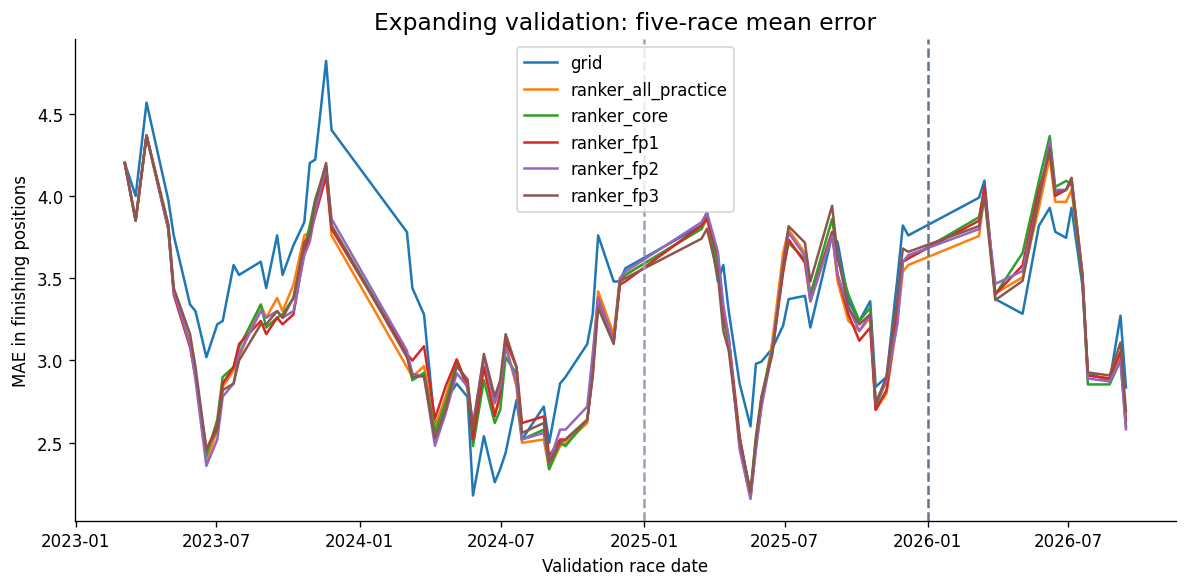

,period,model,races,mae_change_vs_core,paired_95_low,paired_95_high
0,2023–24 selection,ranker_fp1,46,0.009,-0.030,0.050
1,2023–24 selection,ranker_fp2,46,0.004,-0.039,0.052
2,2023–24 selection,ranker_fp3,46,0.011,-0.028,0.057
3,2023–24 selection,ranker_all_practice,46,0.004,-0.028,0.037
4,2025 calibration,ranker_fp1,24,-0.025,-0.075,0.021
5,2025 calibration,ranker_fp2,24,-0.012,-0.067,0.046
6,2025 calibration,ranker_fp3,24,0.004,-0.050,0.058
7,2025 calibration,ranker_all_practice,24,-0.021,-0.083,0.046
8,2026 audit,ranker_fp1,14,0.000,-0.065,0.045
9,2026 audit,ranker_fp2,14,-0.032,-0.091,0.026


In [16]:
(oof, metrics, folds) = walk_forward(data, specs, validation_since=2023)
dev_metrics = metrics.loc[metrics.season.le(2024)]
assert dev_metrics.race_id.nunique() >= 20
selection = dev_metrics.groupby("model")[
    ["mae", "spearman", "top3_overlap", "top10_overlap", "pairwise_accuracy"]
].mean()
selection = selection.sort_values(["mae", "pairwise_accuracy"], ascending=[True, False])
CHOSEN = selection.index[0]
print("Selected model:", CHOSEN)
display(selection.round(3))
metrics["period"] = np.select(
    [metrics.season.le(2024), metrics.season.eq(2025)],
    ["2023–24 selection", "2025 calibration"],
    default="2026 audit",
)
display(
    metrics.groupby(["period", "model"])[
        ["mae", "spearman", "top3_overlap", "top10_overlap", "pairwise_accuracy"]
    ]
    .mean()
    .round(3)
)
folds.to_csv(OUT / "validation_folds.csv", index=False)
metrics.to_csv(OUT / "race_metrics.csv", index=False)
oof.to_csv(OUT / "out_of_fold_predictions.csv", index=False)
(fig, ax) = plt.subplots(figsize=(10, 5))
for (kind, g) in metrics.groupby("model"):
    if kind == "grid" or kind.startswith("ranker"):
        ax.plot(
            pd.to_datetime(g.date), g.mae.rolling(5, min_periods=1).mean(), label=kind
        )
ax.axvline(pd.Timestamp("2025-01-01", tz="UTC"), color="#94a3b8", linestyle="--")
ax.axvline(pd.Timestamp("2026-01-01", tz="UTC"), color="#64748b", linestyle="--")
ax.set(
    title="Expanding validation: five-race mean error",
    ylabel="MAE in finishing positions",
    xlabel="Validation race date",
)
ax.legend()
savefig("model_validation")

# Compare the same validation races; negative MAE differences favor practice.
practice_comparison = []
for period, part in metrics.groupby("period", sort=False):
    paired = part.pivot(index=["date", "race_id"], columns="model", values="mae").sort_index()
    rng = np.random.default_rng(SEED)
    count = len(paired)
    starts = rng.integers(0, count, size=(3000, int(np.ceil(count / 5))))
    indices = ((starts[:, :, None] + np.arange(5)) % count).reshape(3000, -1)[:, :count]
    for kind in ["ranker_fp1", "ranker_fp2", "ranker_fp3", "ranker_all_practice"]:
        if kind not in paired:
            continue
        difference = (paired[kind] - paired.ranker_core).to_numpy()
        assert np.isfinite(difference).all()
        lower, upper = np.quantile(difference[indices].mean(axis=1), [0.025, 0.975])
        practice_comparison.append({"period": period, "model": kind, "races": count,
                                    "mae_change_vs_core": difference.mean(),
                                    "paired_95_low": lower, "paired_95_high": upper})
practice_comparison = pd.DataFrame(practice_comparison)
display(practice_comparison.round(3))
practice_comparison.to_csv(OUT / "practice_comparison.csv", index=False)


## How uncertain is the forecast?

I resample earlier out-of-fold race errors to generate complete finishing orders.
The probabilities are approximate; zero in these simulations does not mean impossible.

In [17]:
def simulate_order(base_ranks, calibration, draws=6000, seed=SEED):
    """Resample whole-race rank-error vectors aligned by predicted percentile.

    Preserves broad shared-event structure. Interpolate for 20/22-car fields.
    Includes empirical retirement tails; no second DNF penalty is added.
    """
    rng = np.random.default_rng(seed)
    n = len(base_ranks)
    races = [g.sort_values("predicted_rank") for _, g in calibration.groupby("race_id")]
    if len(races) < 10:
        raise ValueError("At least ten earlier OOF races needed for uncertainty.")
    base = (np.asarray(base_ranks) - 1) / (n - 1)
    simulated = np.empty((draws, n), dtype=int)
    for b in range(draws):
        g = races[rng.integers(len(races))]
        xp = (g.predicted_rank.to_numpy() - 1) / (len(g) - 1)
        eps = np.interp(base, xp, g.residual_norm.to_numpy())
        latent = base + eps + rng.normal(0, 1e-6, n)
        order = np.argsort(latent, kind="stable")
        simulated[b, order] = np.arange(1, n + 1)
    assert np.all(np.sort(simulated, axis=1) == np.arange(1, n + 1))
    return simulated


def probability_audit(oof, chosen, calibration_year=2025, audit_year=2026):
    p = oof.loc[oof.model.eq(chosen)].copy()
    rows = []
    for race, g in p.loc[p.season.ge(audit_year)].groupby("race_id", sort=True):
        earlier = p.loc[p.date.lt(g.date.min()) & p.season.ge(calibration_year)]
        if earlier.race_id.nunique() < 10:
            continue
        sim = simulate_order(g.predicted_rank.to_numpy(), earlier, draws=2000)
        lo, hi = np.quantile(sim, [0.1, 0.9], axis=0, method="nearest")
        prob = (sim <= 3).mean(axis=0)
        y = g.position.le(3).to_numpy()
        for k, r in enumerate(g.itertuples()):
            rows.append(
                {
                    "race_id": race,
                    "driverId": r.driverId,
                    "podium_probability": prob[k],
                    "podium_actual": int(y[k]),
                    "covered80": int(lo[k] <= r.position <= hi[k]),
                    "interval_width": hi[k] - lo[k],
                    "brier": float((prob[k] - y[k]) ** 2),
                }
            )
    return pd.DataFrame(rows)

,model,audit_races,mean_mae,race_bootstrap_lo,race_bootstrap_hi
0,gradient_boosting,14,3.442,2.805,4.117
1,grid,14,3.403,2.850,3.974
2,random_forest,14,3.390,2.799,3.994
3,ranker_all_practice,14,3.422,2.818,4.058
4,ranker_core,14,3.481,2.825,4.169
5,ranker_fp1,14,3.481,2.864,4.143
6,ranker_fp2,14,3.448,2.844,4.123
7,ranker_fp3,14,3.487,2.903,4.084
8,recent_form,14,4.364,3.786,4.994


brier              0.070509
covered80          0.850649
interval_width    11.379870
Name: 2026 audit, dtype: float64

,predicted,observed,n
podium_probability,,,
"(-0.001, 0.1]",0.009650,0.022727,220
"(0.1, 0.25]",0.122688,0.125000,32
"(0.25, 0.5]",0.429167,0.541667,24
"(0.5, 0.75]",0.652600,0.500000,10
"(0.75, 1.0]",0.869318,0.681818,22


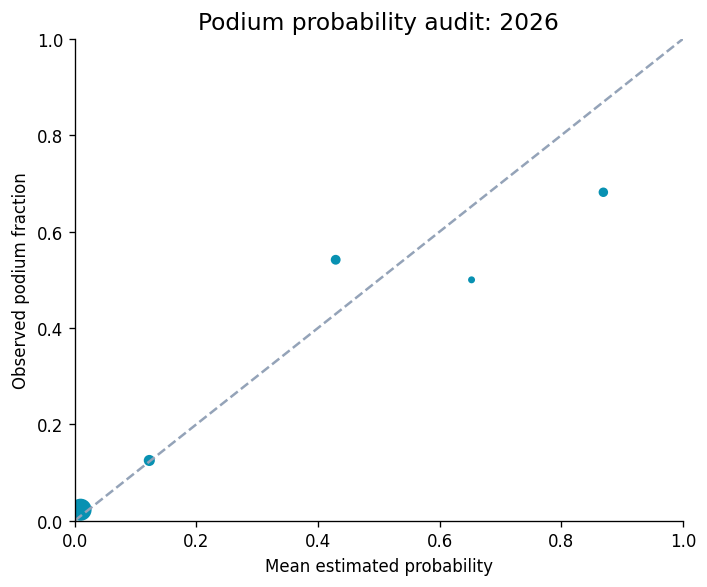

In [18]:
audit = metrics.loc[metrics.season.eq(2026)]
rng = np.random.default_rng(42)
bootstrap = []
for (kind, g) in audit.groupby("model"):
    vals = g.mae.to_numpy()
    samples = rng.choice(vals, size=(3000, len(vals)), replace=True).mean(axis=1)
    bootstrap.append(
        {
            "model": kind,
            "audit_races": len(vals),
            "mean_mae": vals.mean(),
            "race_bootstrap_lo": np.quantile(samples, 0.025),
            "race_bootstrap_hi": np.quantile(samples, 0.975),
        }
    )
display(pd.DataFrame(bootstrap).round(3))
prob_audit = probability_audit(oof, CHOSEN)
if not prob_audit.empty:
    display(
        prob_audit[["brier", "covered80", "interval_width"]].mean().rename("2026 audit")
    )
    bins = pd.cut(
        prob_audit.podium_probability, [0, 0.1, 0.25, 0.5, 0.75, 1], include_lowest=True
    )
    reliability = prob_audit.groupby(bins, observed=True).agg(
        predicted=("podium_probability", "mean"),
        observed=("podium_actual", "mean"),
        n=("podium_actual", "size"),
    )
    display(reliability)
    (fig, ax) = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], linestyle="--", color="#94a3b8")
    ax.scatter(
        reliability.predicted,
        reliability.observed,
        s=reliability.n.clip(upper=150),
        color="#0891b2",
    )
    ax.set(
        title="Podium probability audit: 2026",
        xlabel="Mean estimated probability",
        ylabel="Observed podium fraction",
        xlim=(0, 1),
        ylim=(0, 1),
    )
    savefig("probability_reliability")
else:
    print("Not enough later audit races for probability diagnostics.")
prob_audit.to_csv(OUT / "probability_audit.csv", index=False)

## My Baku prediction

The best development model is refit on all eligible earlier races. The intervals include
historical non-finish outcomes, but cannot anticipate a particular strategy or incident.

Model: ranker_core | Empirical error races: 38
Grid: Derived provisional grid: workbook qualifying plus documented Aston Martin back-of-grid penalties; final FIA grid and pending investigations unconfirmed


,predicted_position,driver,team,qual_pos,expected_finish,p10_position,p90_position,podium_probability,top10_probability
0,1,George Russell,Mercedes,1,2.653,1,4,0.896,0.927
1,2,Charles Leclerc,Ferrari,2,4.538,1,17,0.737,0.893
2,3,Isack Hadjar,Red Bull Racing,4,6.897,1,21,0.413,0.821
3,4,Oscar Piastri,McLaren,3,5.615,2,16,0.476,0.838
4,5,Lando Norris,McLaren,5,6.532,3,14,0.134,0.874
5,6,Lewis Hamilton,Ferrari,6,6.854,3,13,0.126,0.867
6,7,Max Verstappen,Red Bull Racing,8,8.890,3,18,0.104,0.731
7,8,Kimi Antonelli,Mercedes,16,10.339,5,21,0.030,0.588
8,9,Pierre Gasly,Alpine,7,11.358,6,19,0.031,0.588
9,10,Franco Colapinto,Alpine,10,11.009,6,19,0.000,0.609


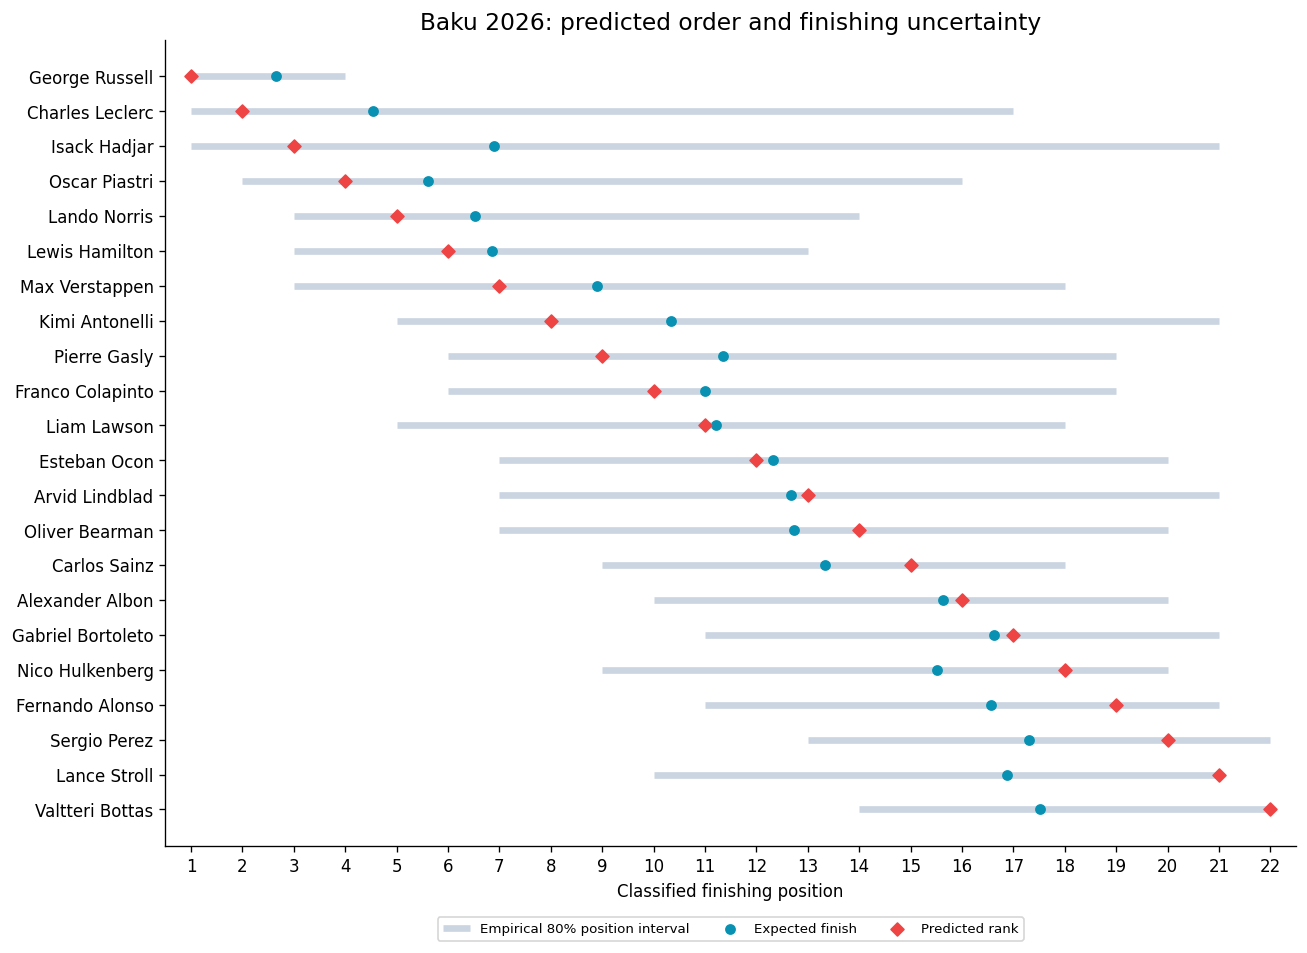

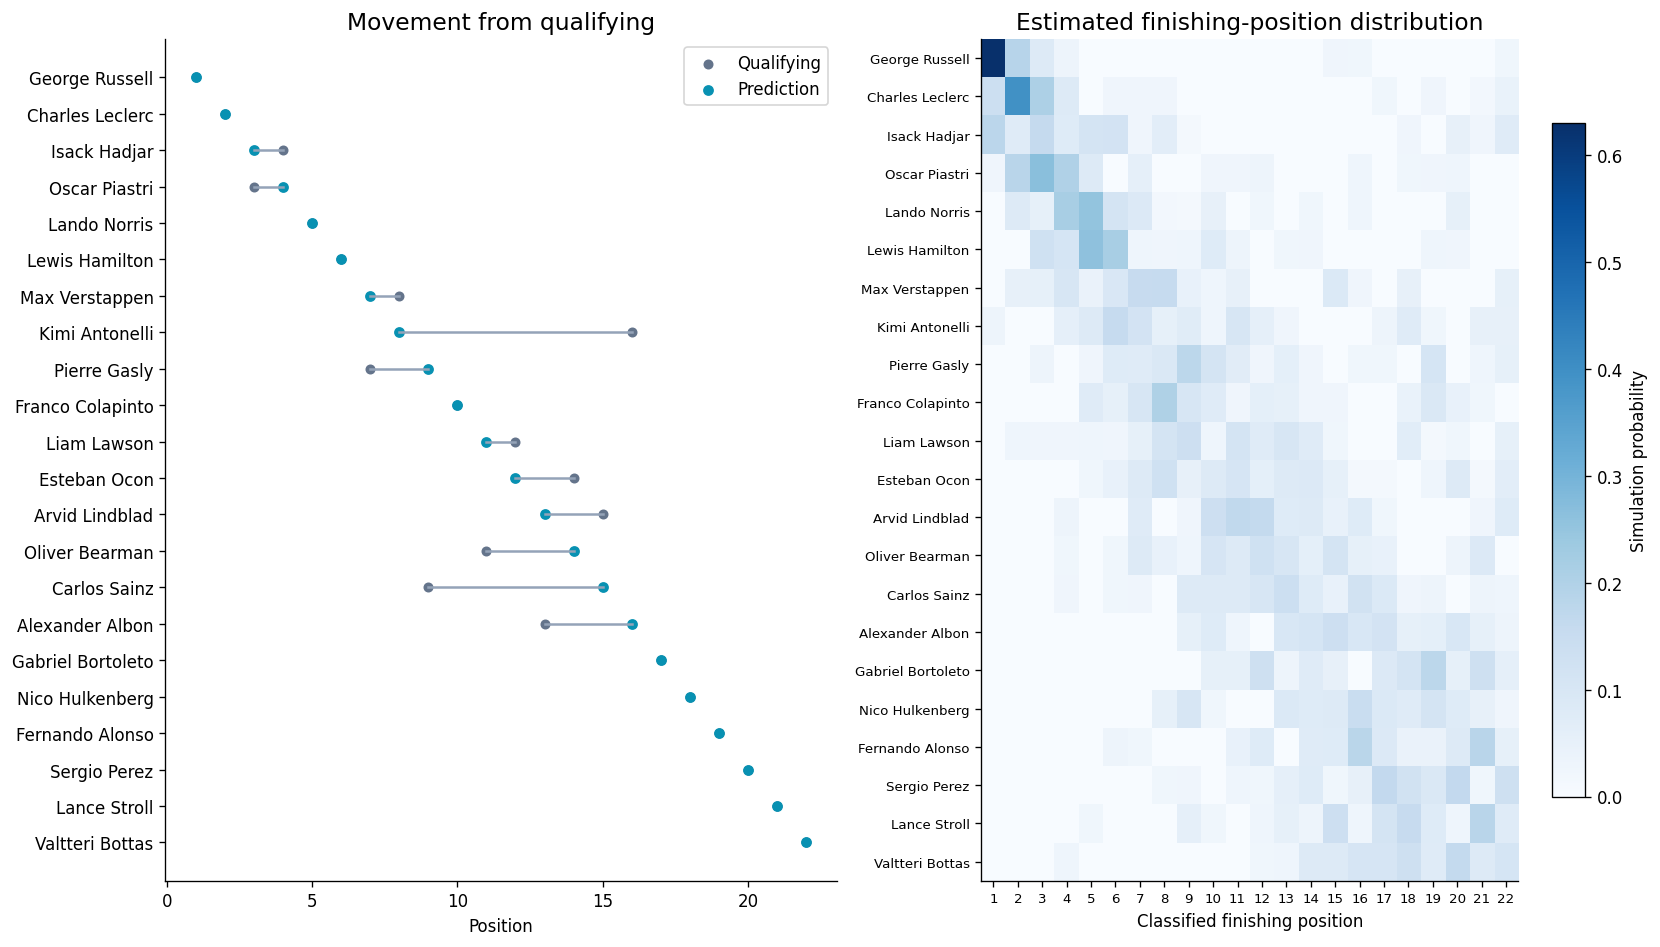

In [19]:
selected_features = specs[CHOSEN]
model = fit_model(CHOSEN, data, selected_features)
scores = scores_for(CHOSEN, model, inputs, selected_features)
ranks = order_scores(scores, inputs)
calibration = oof.loc[
    oof.model.eq(CHOSEN) & oof.season.ge(2025) & oof.date.lt(AS_OF_UTC)
].copy()
sim = simulate_order(ranks, calibration, draws=N_SIMULATIONS)
(lo, hi) = np.quantile(sim, [0.1, 0.9], axis=0, method="nearest")
prediction = inputs[
    ["driverId", "driver", "team", "qual_pos", "grid", "grid_source", "grid_status"]
].copy()
prediction["predicted_position"] = ranks
prediction["expected_finish"] = sim.mean(axis=0)
prediction["p10_position"] = lo.astype(int)
prediction["p90_position"] = hi.astype(int)
prediction["podium_probability"] = (sim <= 3).mean(axis=0)
prediction["win_probability"] = (sim == 1).mean(axis=0)
prediction["top10_probability"] = (sim <= 10).mean(axis=0)
prediction["places_vs_qualifying"] = prediction.qual_pos - prediction.predicted_position
prediction = prediction.sort_values("predicted_position").reset_index(drop=True)
assert sorted(prediction.predicted_position) == list(range(1, len(inputs) + 1))
assert np.isclose(prediction.podium_probability.sum(), 3)
assert np.isclose(prediction.win_probability.sum(), 1)
assert np.isclose(prediction.top10_probability.sum(), 10)
print("Model:", CHOSEN, "| Empirical error races:", calibration.race_id.nunique())
print("Grid:", prediction.grid_status.iloc[0])
display(
    prediction[
        [
            "predicted_position",
            "driver",
            "team",
            "qual_pos",
            "expected_finish",
            "p10_position",
            "p90_position",
            "podium_probability",
            "top10_probability",
        ]
    ].round(3)
)
(fig, ax) = plt.subplots(figsize=(11, 8))
y = np.arange(len(prediction))
ax.hlines(
    y,
    prediction.p10_position,
    prediction.p90_position,
    color="#cbd5e1",
    linewidth=4,
    zorder=1,
    label="Empirical 80% position interval",
)
ax.scatter(
    prediction.expected_finish,
    y,
    s=30,
    color="#0891b2",
    zorder=3,
    label="Expected finish",
)
ax.scatter(
    prediction.predicted_position,
    y,
    s=30,
    color="#ef4444",
    marker="D",
    zorder=3,
    label="Predicted rank",
)
ax.set_yticks(y, prediction.driver)
ax.invert_yaxis()
ax.set_xticks(range(1, len(prediction) + 1))
ax.set_xlim(0.5, len(prediction) + 0.5)
ax.set(
    title="Baku 2026: predicted order and finishing uncertainty",
    xlabel="Classified finishing position",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)
savefig("predicted_finishing_order")
(fig, axes) = plt.subplots(1, 2, figsize=(14, 8))
for (i, r) in enumerate(prediction.itertuples()):
    axes[0].plot([r.qual_pos, r.predicted_position], [i, i], color="#94a3b8")
axes[0].scatter(prediction.qual_pos, y, label="Qualifying", color="#64748b", s=25)
axes[0].scatter(
    prediction.predicted_position, y, label="Prediction", color="#0891b2", s=30
)
axes[0].set_yticks(y, prediction.driver)
axes[0].invert_yaxis()
axes[0].set(title="Movement from qualifying", xlabel="Position")
axes[0].legend()
ordered_indices = [
    int(np.where(inputs.driverId.to_numpy() == d)[0][0]) for d in prediction.driverId
]
probabilities = np.array(
    [
        (sim[:, i, None] == np.arange(1, len(inputs) + 1)).mean(axis=0)
        for i in ordered_indices
    ]
)
im = axes[1].imshow(probabilities, aspect="auto", cmap="Blues", vmin=0)
axes[1].set_yticks(y, prediction.driver, fontsize=8)
axes[1].set_xticks(range(len(inputs)), range(1, len(inputs) + 1), fontsize=8)
axes[1].set(
    title="Estimated finishing-position distribution",
    xlabel="Classified finishing position",
)
fig.colorbar(im, ax=axes[1], label="Simulation probability", shrink=0.8)
savefig("qualifying_movement_and_probabilities")

## What drives the order?

Permutation importance uses held-out races. SHAP explains ranking scores, not causal effects
or positions gained.

In [20]:
def permutation_importance_races(model, kind, frame, features, repeats=4):
    """Within-race permutations; evaluate on a held-out block only."""
    rng = np.random.default_rng(SEED)

    def mae(f):
        values = []
        for _, g in f.groupby("race_id"):
            pred = order_scores(scores_for(kind, model, g, features), g)
            values.append(np.abs(pred - g.position.to_numpy()).mean())
        return float(np.mean(values))

    base = mae(frame)
    rows = []
    for feature in features:
        losses = []
        for _ in range(repeats):
            shuffled = frame.copy()
            for _, idx in shuffled.groupby("race_id").groups.items():
                shuffled.loc[idx, feature] = rng.permutation(
                    shuffled.loc[idx, feature].to_numpy()
                )
            losses.append(mae(shuffled) - base)
        rows.append(
            {"feature": feature, "mae_increase": np.mean(losses), "std": np.std(losses)}
        )
    return pd.DataFrame(rows).sort_values("mae_increase", ascending=False)

,feature,mae_increase,std
0,grid_norm,0.514,0.082
4,q3_gap_pct,0.157,0.028
6,team_qual_norm,0.132,0.029
1,qual_norm,0.096,0.031
27,recent_race_pace,0.096,0.026
8,driver_points_5,0.065,0.031
13,team_points_5,0.063,0.023
3,q2_gap_pct,0.055,0.019
12,team_finish_5,0.047,0.032
7,driver_finish_5,0.037,0.023


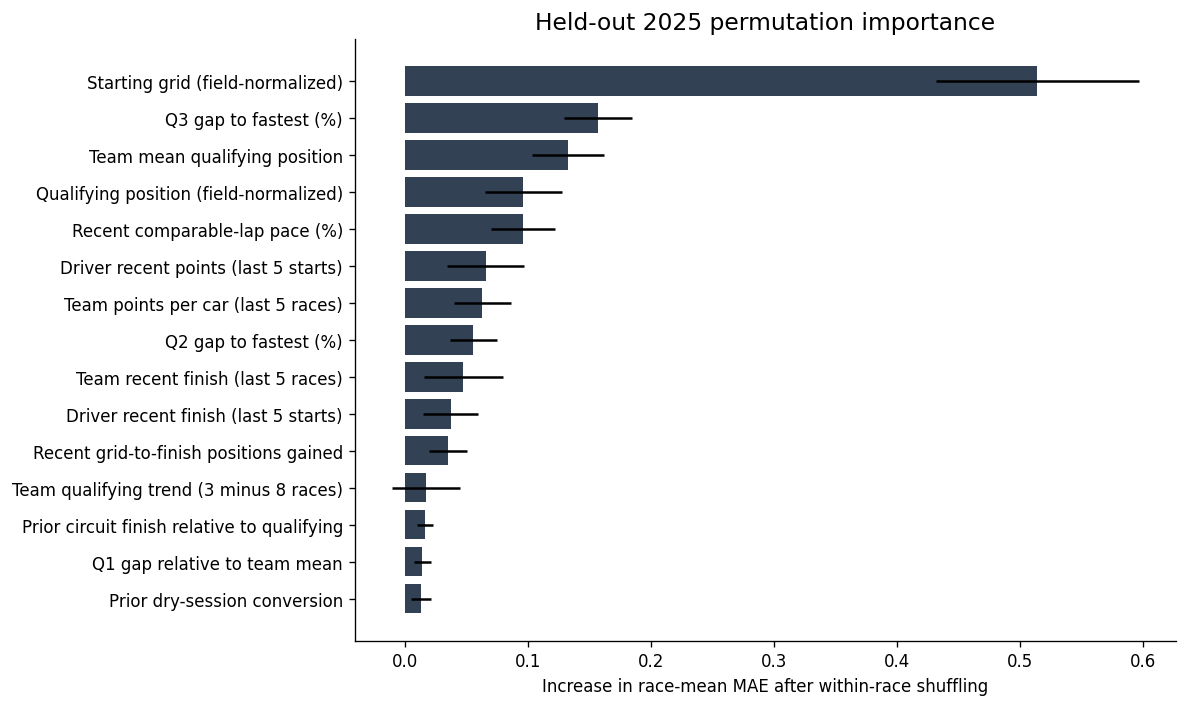

,predicted_position,driver,places_vs_qualifying,key_factors
0,1,George Russell,0,Starting grid (field-normalized): +0.324; Q3 g...
1,2,Charles Leclerc,0,Starting grid (field-normalized): +0.322; Team...
2,3,Isack Hadjar,1,Starting grid (field-normalized): +0.217; Team...
3,4,Oscar Piastri,-1,Starting grid (field-normalized): +0.225; Team...
4,5,Lando Norris,0,Starting grid (field-normalized): +0.204; Team...
5,6,Lewis Hamilton,0,Starting grid (field-normalized): +0.111; Team...
6,7,Max Verstappen,1,Team points per car (last 5 races): +0.137; St...
7,8,Kimi Antonelli,8,Team points per car (last 5 races): +0.156; Dr...
8,9,Pierre Gasly,-2,Starting grid (field-normalized): +0.158; Qual...
9,10,Franco Colapinto,0,Q3 gap to fastest (%): -0.077; Starting grid (...


In [21]:
explain_train = data.loc[data.season.le(2024)]
explain_test = data.loc[data.season.eq(2025)]
explain_model = fit_model(CHOSEN, explain_train, selected_features)
importance = permutation_importance_races(
    explain_model, CHOSEN, explain_test, selected_features
)
display(importance.head(15).round(3))
(fig, ax) = plt.subplots(figsize=(10, 6))
imp = importance.head(15).sort_values("mae_increase")
ax.barh(
    imp.feature.map(lambda f: FEATURE_LABELS.get(f, f)),
    imp.mae_increase,
    xerr=imp["std"],
    color="#334155",
)
ax.set(
    title="Held-out 2025 permutation importance",
    xlabel="Increase in race-mean MAE after within-race shuffling",
)
savefig("feature_importance")
if CHOSEN.startswith("ranker"):
    import xgboost as xgb

    contrib = model.get_booster().predict(
        xgb.DMatrix(inputs[selected_features]), pred_contribs=True
    )
    assert np.allclose(contrib.sum(axis=1), scores, atol=0.0001)
    local = pd.DataFrame(
        contrib[:, :-1], columns=selected_features, index=inputs.driverId
    )
    explanation_type = (
        "Exact tree SHAP; positive supports better rank; latent score units"
    )
else:
    local = pd.DataFrame(0.0, index=inputs.driverId, columns=selected_features)
    if CHOSEN == "grid":
        local["grid_norm"] = -inputs.grid_norm.to_numpy() + float(
            data.grid_norm.median()
        )
    elif CHOSEN == "recent_form":
        local["driver_finish_5"] = -inputs.driver_finish_5.fillna(
            0.5
        ).to_numpy() + float(data.driver_finish_5.median())
    else:
        for f in selected_features:
            changed = inputs.copy()
            changed[f] = data[f].median()
            local[f] = scores - scores_for(CHOSEN, model, changed, selected_features)
    explanation_type = (
        "One-feature training-median replacement sensitivity; not SHAP or causation"
    )
reasons = []
for r in prediction.itertuples():
    effects = local.loc[r.driverId]
    top = effects.abs().sort_values(ascending=False).head(3).index
    reasons.append(
        "; ".join(
            (
                f"{FEATURE_LABELS.get(f, f)}: {effects[f]:+.3f}"
                for f in top
                if abs(effects[f]) > 1e-10
            )
        )
    )
prediction["key_factors"] = reasons
prediction["explanation_type"] = explanation_type
display(
    prediction[["predicted_position", "driver", "places_vs_qualifying", "key_factors"]]
)
local.to_csv(OUT / "driver_feature_contributions.csv")
importance.to_csv(OUT / "permutation_importance.csv", index=False)

## Save the forecast

In [22]:
prediction.to_csv(OUT / "baku_predictions.csv", index=False)
print("Saved results/baku_predictions.csv")

Saved results/baku_predictions.csv
